# Deep Learning Project : Intrusion Detection System (IDS)

The CSE-CIC-IDS2018 dataset is a comprehensive network intrusion detection dataset developed collaboratively by the Canadian Institute for Cybersecurity (CIC) and the Communications Security Establishment (CSE). It is designed to provide a realistic and up-to-date benchmark for evaluating intrusion detection systems (IDS) and machine learning-based security solutions.
tWe didn’t extract all the type of possible attacks. Given the over representation of DoS attacks, we decided to only use 6 possible attacks: DoS-GoldenEye, Infiltration, DoS-SlowLoris, BruteForce-Web, BruteForce-XSS and SQL Injections.
From each packet, we extract information from both the TCP and the IP layer. 
Based on TCP/IP infrastructure, we can choose which information we want to extract

We have decided to extract the following:
-	Source & destination ports
-	Data offset
-	Flags
-	Window 
-	IHL
-	Type Of Service
-	Total Length
-	Identification
-	Flags
-	Time to live
-	Po
On top of the Header data, we also want to include the payload (if any).

Payload
Contrary to the header, the payload does not have a fixed size. To cater for this fact, we decided to normalize the data using the following algorithm:
-	If the payload does not exist, we fix it at a ‘000.0000’ value.
-	If it exists, we check if it is longer than 10         bits
a.	If not, we display the payload in a 10 bit long array (filling the missing value by addin        g a 0
b.	If it exists, we split the payload in quintile and calculate the Shannon entropy for each quintile


Shannon entropy measures the uncertainty or randomness in a dataset, often used to quantify information content. Higher entropy means more unpredictability, while lower entropy indicates more structure or reduAnd we calculated the entropy for 10 quantilesndancy. tocol
ize
.



In [1]:
import pyshark
import re
import json
import pandas as pd
from urllib.parse import urlparse
from urllib.parse import parse_qs, unquote
import ipaddress
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import seaborn as sns

##### Since the data has around 3 million records we can load them in two different data sets that will be useful if we create advanced deep learning models. 

In [2]:
#loading the first set of 10 files
parquet_files = [f"output_part_{i}.parquet" for i in range(11)]
dfs = [pd.read_parquet(file) for file in parquet_files]
df = pd.concat(dfs, ignore_index=True)

In [3]:
#loading the second set of 10 files
parquet_files1 = [f"output_part_{i}.parquet" for i in range(11,21)]
dfs1 = [pd.read_parquet(file) for file in parquet_files1]
df1 = pd.concat(dfs1, ignore_index=True)

In [4]:
#creating a full dataset using the Pandas concat function.
dfs=[df,df1]
dff=pd.concat(dfs)
print(dff)

         Entropy_1  Entropy_2  Entropy_3  Entropy_4  Entropy_5  Entropy_6  \
0         0.385657   0.000000   0.000000        0.0        0.0        0.0   
1         0.385657   0.379065   0.377339        0.0        0.0        0.0   
2         0.000000   0.000000   0.000000        0.0        0.0        0.0   
3         0.000000   0.000000   0.000000        0.0        0.0        0.0   
4         0.000000   0.000000   0.000000        0.0        0.0        0.0   
...            ...        ...        ...        ...        ...        ...   
1361373   0.374567   0.000000   0.000000        0.0        0.0        0.0   
1361374   0.380112   0.000000   0.000000        0.0        0.0        0.0   
1361375   0.000000   0.000000   0.000000        0.0        0.0        0.0   
1361376   0.377339   0.000000   0.000000        0.0        0.0        0.0   
1361377   0.000000   0.000000   0.000000        0.0        0.0        0.0   

         Entropy_7  Entropy_8  Entropy_9  Entropy_10  ...  Header_bit_139  

In [6]:
#exporting the dataframe as a csv file
dff.to_csv('data_for_read.csv', index=False)


In [8]:
dff.describe(include='all')

,Entropy_1,Entropy_2,Entropy_3,Entropy_4,Entropy_5,Entropy_6,Entropy_7,Entropy_8,Entropy_9,Entropy_10,...,Header_bit_139,Header_bit_140,Header_bit_141,Header_bit_142,Header_bit_143,Header_bit_144,PayloadEncoding,PayloadStrings,Attack,Label
count,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,...,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,2.940417e+06,462935,872000,2940417,2940417
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,22,537819,7,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ascii,GET / HTTP/1.1\r Host: 18.217.21.148\r User-Ag...,Benign,Benign
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,207831,49282,2657690,2657690
mean,1.359738e-01,1.202111e-01,1.121937e-01,1.073145e-01,9.959707e-02,9.431458e-02,9.188724e-02,8.830504e-02,8.513616e-02,8.320669e-02,...,3.497535e-01,5.005011e-01,3.395311e-01,3.990026e-01,4.164409e-01,3.658709e-01,NaN,NaN,NaN,NaN
std,1.745367e-01,1.704678e-01,1.661206e-01,1.640704e-01,1.627995e-01,1.601196e-01,1.587873e-01,1.573558e-01,1.560112e-01,1.547626e-01,...,4.768921e-01,4.999998e-01,4.735502e-01,4.896934e-01,4.929685e-01,4.816736e-01,NaN,NaN,NaN,NaN
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN
75%,3.523861e-01,3.374766e-01,3.154702e-01,3.088205e-01,3.136056e-01,3.071524e-01,2.848332e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN


# EDA

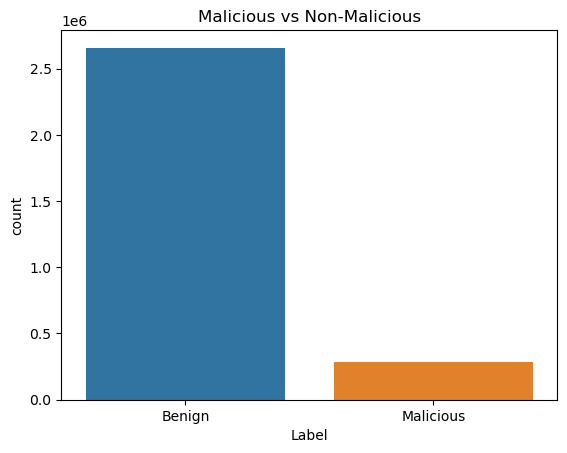

In [9]:
sns.countplot(x='Label', data=dff)
plt.title("Malicious vs Non-Malicious")
plt.savefig("malicious_vs_non_malicious_bar_graph.png", dpi=300, bbox_inches='tight')
plt.show()

##### From the visual analysis we can see that there is a lot of imbalance in the data. We have a lot of Benign compared to Malicious. This might cause issues in terms of accuracy of the model. 

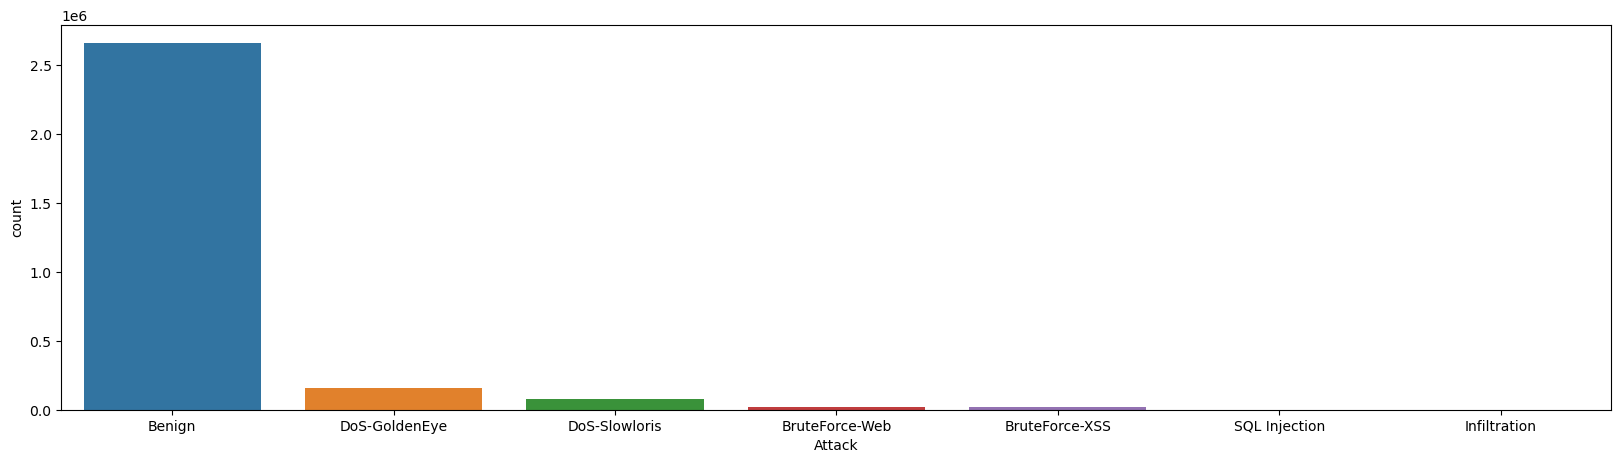

In [13]:
# Set figure size first
plt.figure(figsize=(20, 5))
# Create bar plot
sns.countplot(x='Attack', data=dff)
# Save the plot
plt.savefig("attack_distribution.png", dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

##### Most of the attacks are DoS-GoldenEye and DoS-Slowloris. We donot have a lot of SQL injection or Infiltration attacks 

In [14]:
print(dff['Label'].value_counts(normalize=True))

Label
Benign       0.903848
Malicious    0.096152
Name: proportion, dtype: float64


##### Only 9.6% of the dataset is a malicious target. 

##### Analysis of correlation between the entropy features
We can analyze the following:
> Are certain entropy ranges common in malicious samples?
> Are the features highly correlated (redundant)?

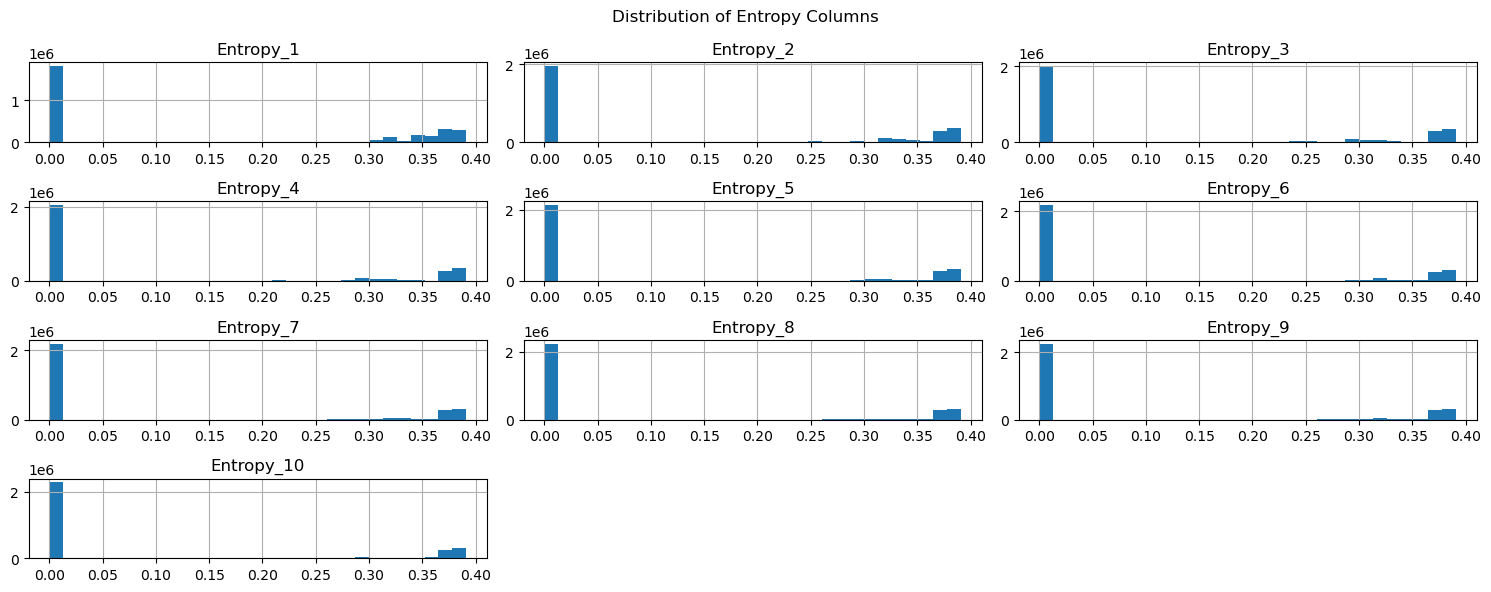

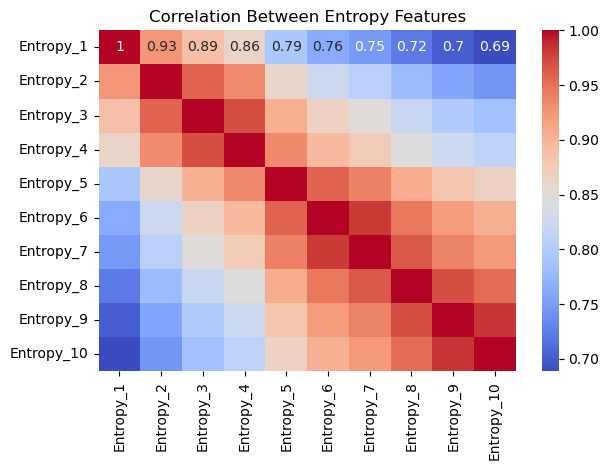

In [25]:
entropy_cols = [f"Entropy_{i}" for i in range(1, 11)]
dff[entropy_cols].describe()
dff[entropy_cols].hist(figsize=(15, 6), bins=30)
plt.suptitle("Distribution of Entropy Columns")
plt.tight_layout()
plt.savefig("entropy_distribution_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
sns.heatmap(df[entropy_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Entropy Features")
plt.tight_layout()
plt.savefig("entropy_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

1. All of the entropy columns are positively correlated with each other
2. There seems to be a slightly strong correlation between the Entropy of the first 10% and the second 10% of the payload
3. The later the parts seems to be much more correlated between each other. There is medium to strong correlation between last 4 parts of the payload


##### Analysis of correlation between the entropy features only for Malicious payloads

In [17]:
malicious_df = dff[dff['Label'] == "Malicious"].copy()

In [18]:
malicious_df.shape

(282727, 158)

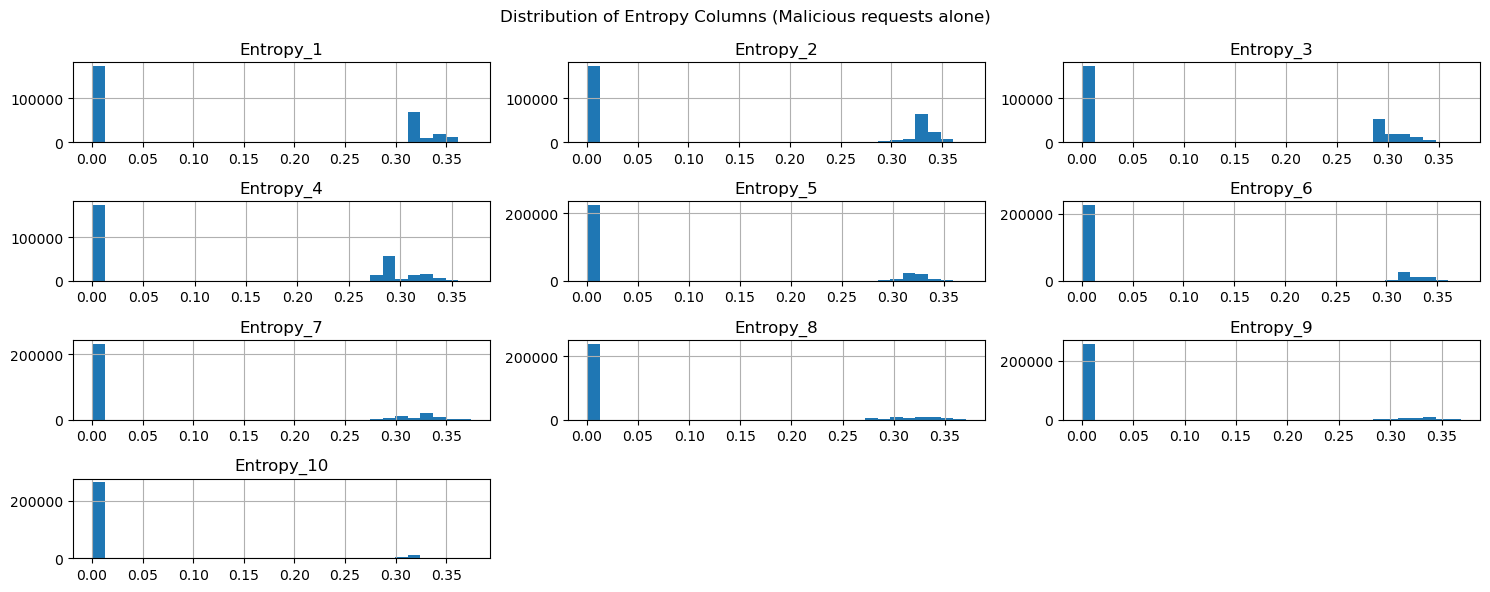

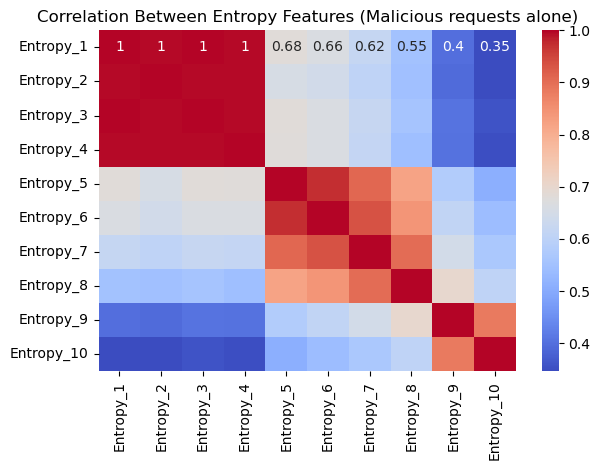

In [19]:
entropy_cols = [f"Entropy_{i}" for i in range(1, 11)]
malicious_df[entropy_cols].describe()
malicious_df[entropy_cols].hist(figsize=(15, 6), bins=30)
plt.suptitle("Distribution of Entropy Columns (Malicious requests alone)")
plt.tight_layout()
plt.savefig("malicious_entropy_distribution_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
sns.heatmap(malicious_df[entropy_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Entropy Features (Malicious requests alone)")
plt.tight_layout()
plt.savefig("malicious_entropy_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

When analyzing the Malicious payloads, we can see that
1. The first 4 entropys are completely correalted. We can see that the entropy ranges are very similar in all of the malicous payloads. This could mean that all of the attacks are having malicious bits in the first 40% of the payload.
2. We can see the correlation going down as we go down the entropy ranges

##### Analysis of Header_Bit columns

In this analysis we will be checking if some bits appear more in malicious cases

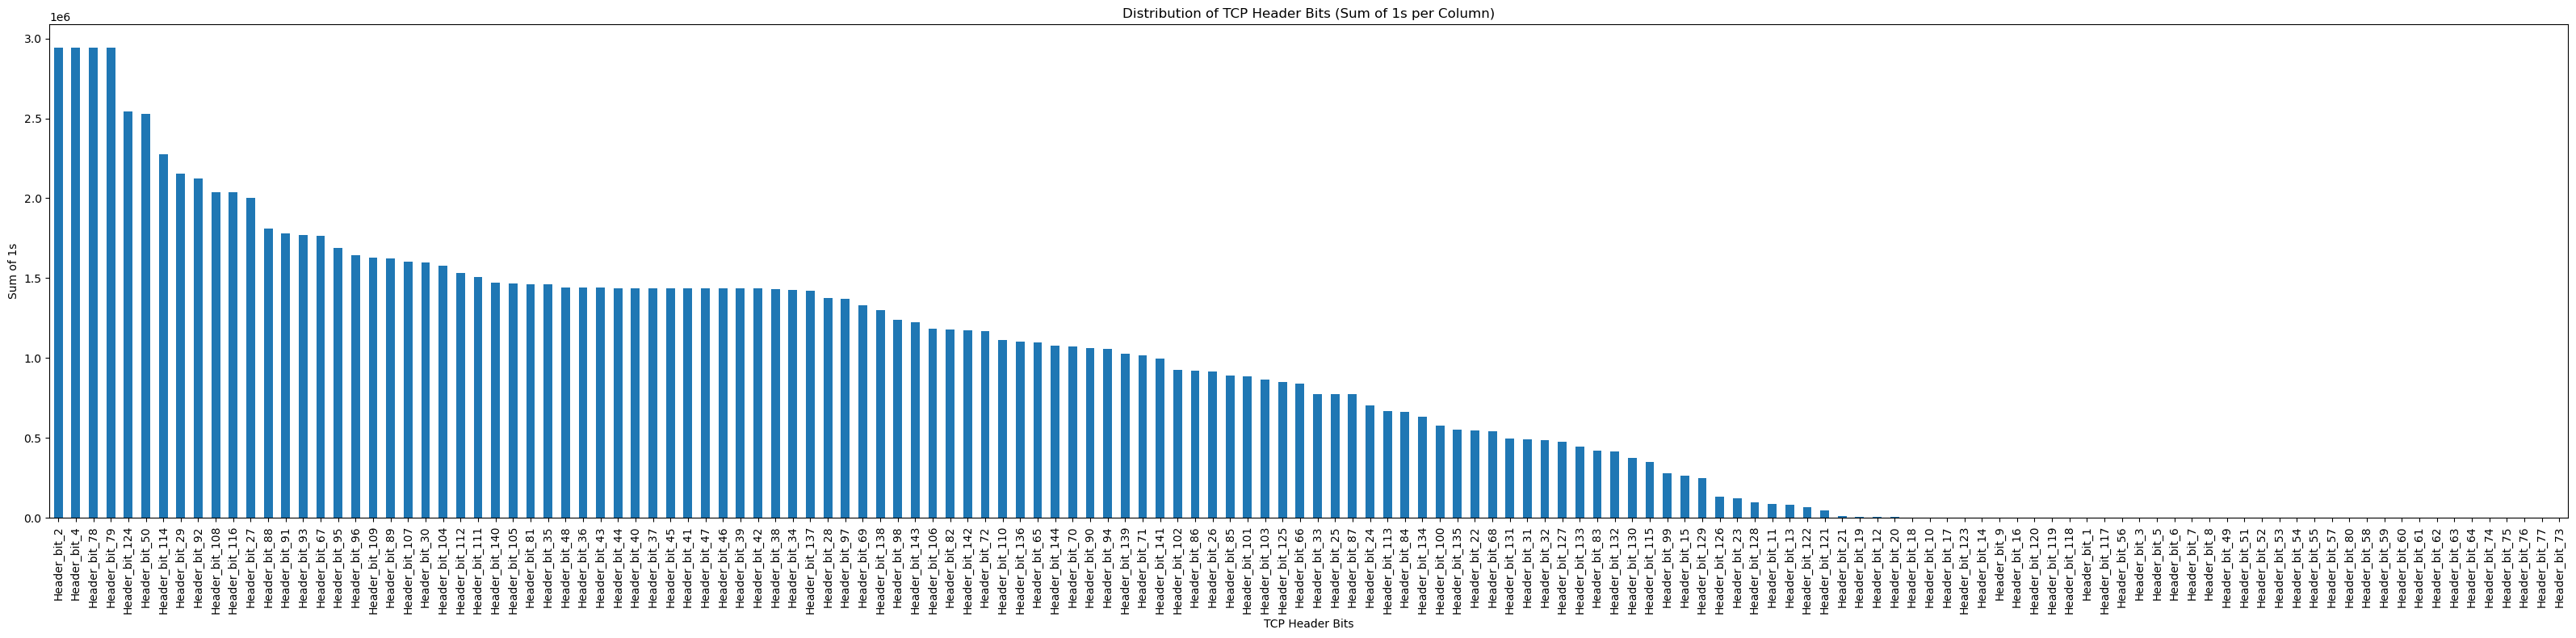

In [20]:
tcp_cols = [col for col in dff.columns if col.startswith("Header_bit")]

# Check for mostly 0 or 1 bits
bit_sums = dff[tcp_cols].sum().sort_values(ascending=False)
bit_sums.plot(kind='bar', figsize=(32, 8))
plt.title("Distribution of TCP Header Bits (Sum of 1s per Column)")
plt.xlabel("TCP Header Bits")
plt.ylabel("Sum of 1s")

# Save the plot
plt.tight_layout()
plt.savefig("tcp_header_bits_distribution.png", dpi=300, bbox_inches='tight')
#show the plot
plt.show()

The header bits 2, 4, 78, 79, 124, 50, 114, 29, 108 have the highest bits in general.

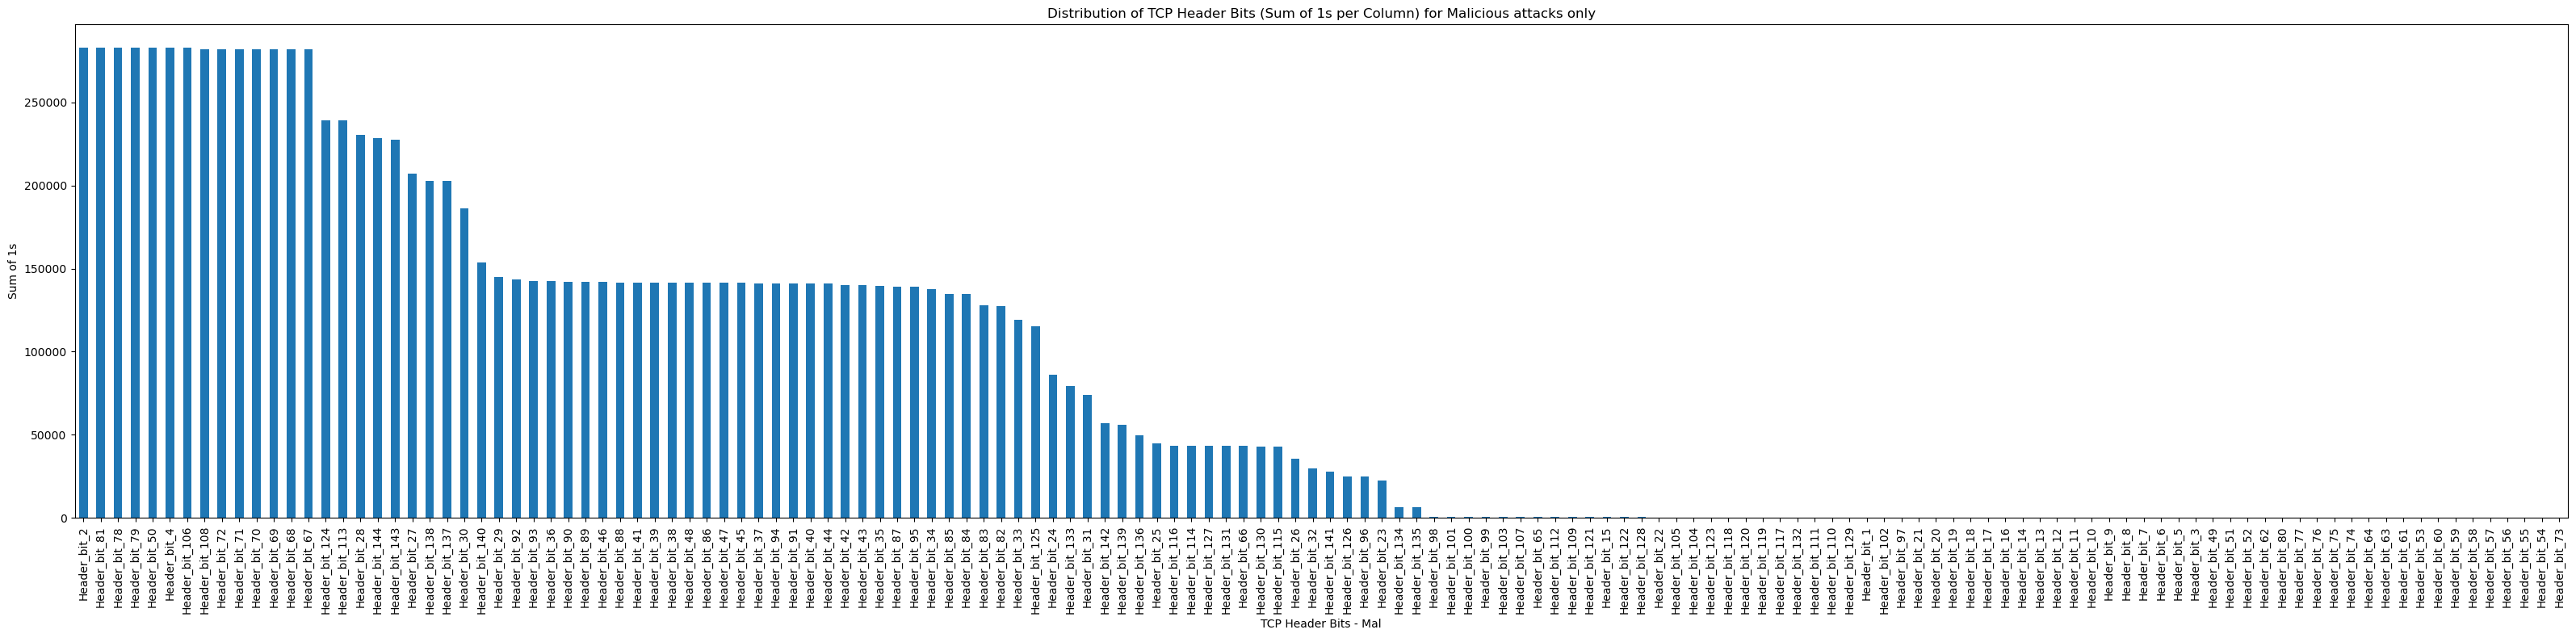

In [21]:
tcp_cols = [col for col in malicious_df.columns if col.startswith("Header_bit")]

# Check for mostly 0 or 1 bits
bit_sums = malicious_df[tcp_cols].sum().sort_values(ascending=False)
bit_sums.plot(kind='bar', figsize=(32, 8))
plt.title("Distribution of TCP Header Bits (Sum of 1s per Column) for Malicious attacks only")
plt.xlabel("TCP Header Bits - Mal")
plt.ylabel("Sum of 1s")

# Save the plot
plt.tight_layout()
plt.savefig("malicious_tcp_header_bits_distribution.png", dpi=300, bbox_inches='tight')
#show the plot
plt.show()

As uspected we can see that the malicious payloads have certain bits present in their payloads.

##### Text analysis of the payload column

C:\Users\susmi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


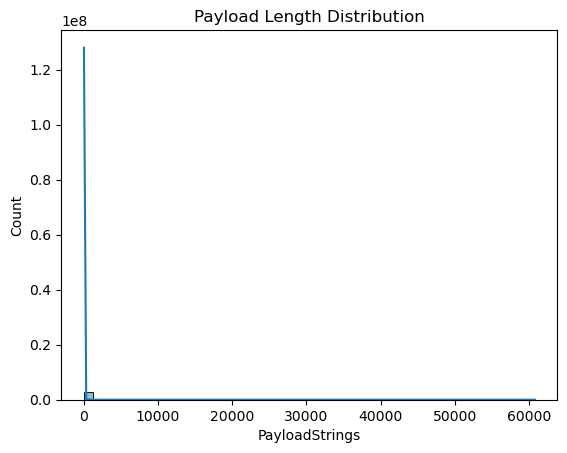

In [22]:
Payload_length = dff['PayloadStrings'].fillna("").apply(len)

sns.histplot(Payload_length, bins=50, kde=True)
plt.title("Payload Length Distribution")
plt.show()

Word cloud analysis Malicious vs Benign

In [23]:
from wordcloud import WordCloud

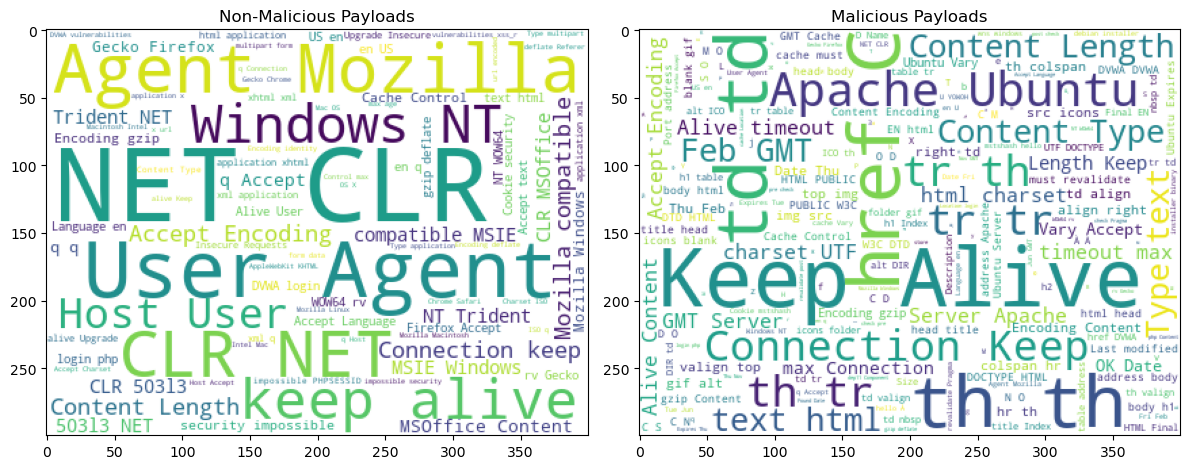

In [24]:
non_mal = " ".join(dff[dff['Label'] == "Malicious"]['PayloadStrings'].dropna().values)
mal = " ".join(dff[dff['Label'] == "Benign"]['PayloadStrings'].dropna().values)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(WordCloud(width=400, height=300, background_color='white').generate(non_mal))
plt.title("Non-Malicious Payloads")

plt.subplot(1, 2, 2)
plt.imshow(WordCloud(width=400, height=300, background_color='white').generate(mal))
plt.title("Malicious Payloads")

# Adjust layout and save
plt.tight_layout()
plt.savefig("payload_wordclouds.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

From the wordcloud we can see the clear difference in text patterns between benign and malicious payloads
1. In the Benign payloads we can see that words like 'User agent' 'NET' 'CLR' are predominant
2. In malicious payloads we can see that User agent or agent is not being defined and we can see a lot of server names such as Apache and Ubuntu

# Model Building

### Approach 1 | Multi-input neural network model

#### Why multi-input neural network model

1. We are working with 3 heterogeneous input types: structured, numerical, and text. A single model can’t handle all 3 well unless you separate inputs.
2. The payload text is often the most critical indicator of malicious behavior, so using LSTM (or even BERT) from the start is good.
3. A simple model (like logistic regression or one big Dense net) might overfit fast or miss nuances across modalities.
4. Multi-branch architectures are common in cybersecurity ML; e.g., detecting phishing, botnet traffic, malware signatures where multiple signals are fused.

In [5]:
#tensorflow installed in the local machine and has been configured to access the local GPU. 

import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [20]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Concatenate, Flatten, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [23]:
from tensorflow.keras.models import load_model

##### loading and preprocessing the first 10 parquet files

In [8]:
#replace 'Benign' with 0 and 'Malicious' by 1
df['Label'] = df['Label'].replace({'Benign': 0, 'Malicious': 1})

In [9]:
print(df['Label'])

0          0
1          0
2          0
3          0
4          0
          ..
1579034    0
1579035    0
1579036    0
1579037    0
1579038    0
Name: Label, Length: 1579039, dtype: int64


In [13]:
entropy_features = df.iloc[:, :10].values  # Next 10 columns (Entropy_1 to Entropy_10)
tcp_features = df.iloc[:, 10:154].values  # First 144 columns (binary TCP header)
payloads = df['PayloadStrings'].fillna("<EMPTY>").astype(str)  # Text payload
labels = df['Label'].values  # Binary classification (0 = benign, 1 = malicious)

print(entropy_features)
print(tcp_features)
print(payloads)
print(labels)

[[0.38565713 0.         0.         ... 0.         0.         0.        ]
 [0.38565713 0.37906545 0.37733936 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.3754298  0.38149825 0.38149825 ... 0.38149825 0.36883813 0.3710875 ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.38011193 0.38427082 0.38427082 ... 0.37404352 0.38149825 0.38427082]]
[[0 1 0 ... 1 0 1]
 [0 1 0 ... 1 0 1]
 [0 1 0 ... 0 0 0]
 ...
 [0 1 0 ... 1 0 0]
 [0 1 0 ... 1 1 1]
 [0 1 0 ... 1 0 0]]
0                                                    <EMPTY>
1          z=7Ж6VXVHтƒж
“aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...
2                                                    <EMPTY>
3                                                    <EMPTY>
4                                                    <EMPTY>
                                 ...                        
1579034                                              <EMPTY>
1579035 

##### loading and preprocessing the second 10 parquet files

In [11]:
df1['Label'] = df1['Label'].replace({'Benign': 0, 'Malicious': 1})

In [12]:
print(df1['Label'])

0          0
1          0
2          0
3          0
4          0
          ..
1361373    0
1361374    0
1361375    0
1361376    0
1361377    0
Name: Label, Length: 1361378, dtype: int64


In [14]:
entropy_features1 = df1.iloc[:, :10].values  # getting entropy features
tcp_features1 = df1.iloc[:, 10:154].values  # getting the header features
payloads1 = df1['PayloadStrings'].fillna("<EMPTY>").astype(str)  # getting the payload text
labels1 = df1['Label'].values  # Binary classification (0 = benign, 1 = malicious)

print(entropy_features1)
print(tcp_features1)
print(payloads1)
print(labels1)

[[0.3768161  0.38149825 0.38097498 ... 0.3795887  0.3768161  0.37872565]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.37318048 0.37733936 0.38288453 ... 0.38288453 0.37872565 0.37872565]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.37733936 0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]
[[0 1 0 ... 1 0 0]
 [0 1 0 ... 1 1 1]
 [0 1 0 ... 1 0 0]
 ...
 [0 1 0 ... 1 1 0]
 [0 1 0 ... 0 1 1]
 [0 1 0 ... 1 1 0]]
0          Ô‘%/<TàÄeÊ∂tóy.Ω◊YﬁÉ™∆§ŸZI
1                                 <EMPTY>
2                                 <EMPTY>
3                                 <EMPTY>
4                                 <EMPTY>
                        ...              
1361373                           <EMPTY>
1361374                           <EMPTY>
1361375                           <EMPTY>
1361376                           <EMPTY>
1361377         

##### Tokenization of the payload texts from all 20 parquet files

In [15]:
#Tokenization and Padding of Payloads (Text Data)
tokenizer = Tokenizer(num_words=5000, oov_token="<UNK>")
tokenizer.fit_on_texts(payloads)
vocab_size = len(tokenizer.word_index) + 1
max_len = 100  # Max sequence length (adjust as needed)
payload_sequences = tokenizer.texts_to_sequences(payloads)
payload_padded = pad_sequences(payload_sequences, maxlen=max_len, padding='post')

In [16]:
tokenizer.fit_on_texts(payloads1)
vocab_size = len(tokenizer.word_index) + 1
max_len = 100  # Max sequence length
payload_sequences1 = tokenizer.texts_to_sequences(payloads1)
payload_padded1 = pad_sequences(payload_sequences1, maxlen=max_len, padding='post')

##### Train test split

In [17]:
X_tcp, X_tcp_test, X_entropy, X_entropy_test, X_payload, X_payload_test, y_train, y_test = train_test_split(
    tcp_features, entropy_features, payload_padded, labels, test_size=0.2, random_state=42
)

In [18]:
X_tcp1, X_tcp_test1, X_entropy1, X_entropy_test1, X_payload1, X_payload_test1, y_train1, y_test1 = train_test_split(
    tcp_features1, entropy_features1, payload_padded1, labels1, test_size=0.2, random_state=42
)

### 1A Approach

#### --------- Do not re-run, Will take 8 hours for one epoch of this hybrid model ----------------- ####

In [12]:
# Input Layer for TCP Header Features
tcp_input = Input(shape=(144,))
tcp_dense = Dense(32, activation='relu')(tcp_input)
tcp_dense = Dense(16, activation='relu')(tcp_dense)

# Input Layer for Entropy Features
entropy_input = Input(shape=(10,))
entropy_dense = Dense(16, activation='relu')(entropy_input)
entropy_dense = Dense(8, activation='relu')(entropy_dense)

# 🔹 Input Layer for Payload (Text)
payload_input = Input(shape=(max_len,))
embedding_layer = Embedding(vocab_size, 128, input_length=max_len)(payload_input)
lstm_layer = LSTM(64, return_sequences=False)(embedding_layer)

# 🔹 Merge all features
merged = Concatenate()([tcp_dense, entropy_dense, lstm_layer])
merged_dense = Dense(32, activation='relu')(merged)
merged_dense = Dense(16, activation='relu')(merged_dense)
output = Dense(1, activation='sigmoid')(merged_dense)  # Sigmoid for binary classification

# 🔹 Define and Compile Model
model = Model(inputs=[tcp_input, entropy_input, payload_input], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔹 Model Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 144)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      4,640 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        176 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 128)  │ 182,754,1… │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │        528 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 8)         │        136 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 88)        │          0 │ dense_8[0][0],    │
│ (Concatenate)       │                   │            │ dense_10[0][0],   │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,848 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │        528 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │         17 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 182,812,457 (697.37 MB)

 Trainable params: 182,812,457 (697.37 MB)

 Non-trainable params: 0 (0.00 B)



#### Why this architecture ?
This is a multi-input neural network — meaning it's designed to process three very different types of data in parallel:
1. TCP Header -> 144 binary bits from TCP header -> Feed into Dense layers
2. Entropy Features -> 10 float values per packet -> Feed into Dense layers
3. Payload (Text) -> Raw payload (after cleaning) -> Feed into an Embedding → LSTM network

##### TCP header layer:
These are 144 binary features (0/1), each representing a flag or bit in the TCP header. Dense layers are great for handling this kind of flat feature vector. Why 32 → 16 nodes? This is a basic compression and feature extraction; we're reducing dimensionality while letting the model learn interactions between bits.

##### Entropy Layer
The entropy values are continuous features (floats), so again we use dense layers. Why 16 → 8? We're letting the model find combinations or patterns in how entropy changes across the payload.

##### LSTM layer for Payload text
LSTMs are great at learning patterns over sequences, like:
- Repeated attack patterns
- Obfuscated payloads
- Command injection syntax
Through embedding the words/tokens are first mapped into vector space (128-dim), so similar words have similar representations.

##### Merge layer
Dense(32 → 16) layers act as a final reasoning unit before classification.
Sigmoid is used at the output because it’s a binary classification problem (malicious vs benign).




In [13]:
# Train Model
history = model.fit(
    [X_tcp, X_entropy, X_payload], y_train,
    validation_data=([X_tcp_test, X_entropy_test, X_payload_test], y_test),
    epochs=1, batch_size=32
)

C:\Users\susmi\anaconda3\Lib\site-packages\tensorflow\python\framework\indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices to a dense Tensor with 182754176 elements. This may consume a large amount of memory.
  warnings.warn(


39476/39476 ━━━━━━━━━━━━━━━━━━━━ 25152s 637ms/step - accuracy: 0.9946 - loss: 0.0163 - val_accuracy: 0.9976 - val_loss: 0.0069


In [18]:
loss, accuracy = model.evaluate([X_tcp_test, X_entropy_test, X_payload_test], y_test)
print(f"Test Accuracy: {accuracy:.4f}")

9869/9869 ━━━━━━━━━━━━━━━━━━━━ 60s 6ms/step - accuracy: 0.9976 - loss: 0.0067
Test Accuracy: 0.9976


#### Training on second set of datasets

In [23]:
# Train Model with second set of data
history = model.fit(
    [X_tcp1, X_entropy1, X_payload1], y_train1,
    validation_data=([X_tcp_test1, X_entropy_test1, X_payload_test1], y_test1),
    epochs=1, batch_size=32
)

C:\Users\susmi\anaconda3\Lib\site-packages\tensorflow\python\framework\indexed_slices.py:446: UserWarning: Converting sparse IndexedSlices to a dense Tensor with 182754176 elements. This may consume a large amount of memory.
  warnings.warn(


34035/34035 ━━━━━━━━━━━━━━━━━━━━ 12398s 364ms/step - accuracy: 0.9995 - loss: 0.0055 - val_accuracy: 0.9997 - val_loss: 0.0012


In [24]:
model.save("model_10PF_K.keras")

#### Checking model performance

In [51]:
model1 = load_model("model_10PF_K.keras")

C:\Users\susmi\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [52]:
loss, accuracy = model1.evaluate([X_tcp_test, X_entropy_test, X_payload_test], y_test)
print(f"Test Accuracy: {accuracy:.4f}")

9869/9869 ━━━━━━━━━━━━━━━━━━━━ 88s 9ms/step - accuracy: 0.9976 - loss: 0.0067
Test Accuracy: 0.9976


In [53]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model1.predict([X_tcp_test, X_entropy_test, X_payload_test])
y_pred_label = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_label))
print(classification_report(y_test, y_pred_label))

9869/9869 ━━━━━━━━━━━━━━━━━━━━ 92s 9ms/step
[[263989    763]
 [     8  51048]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    264752
           1       0.99      1.00      0.99     51056

    accuracy                           1.00    315808
   macro avg       0.99      1.00      1.00    315808
weighted avg       1.00      1.00      1.00    315808



[[263989    763]
 [     8  51048]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    264752
           1       0.99      1.00      0.99     51056

    accuracy                           1.00    315808
   macro avg       0.99      1.00      1.00    315808
weighted avg       1.00      1.00      1.00    315808



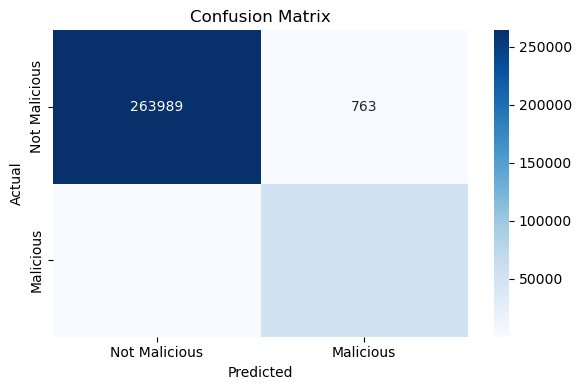

In [54]:
cm = confusion_matrix(y_test, y_pred_label)
print(cm)
print(classification_report(y_test, y_pred_label))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Malicious', 'Malicious'], yticklabels=['Not Malicious', 'Malicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### 1B approach | Addition of dropout layers to prevent overfitting.

In [21]:
# Input Layer for TCP Header Features
tcp_input = Input(shape=(144,))
tcp_dense = Dense(32, activation='relu')(tcp_input)
tcp_dense = Dropout(0.3)(tcp_dense)
tcp_dense = Dense(16, activation='relu')(tcp_dense)
tcp_dense = Dropout(0.3)(tcp_dense)

# Input Layer for Entropy Features
entropy_input = Input(shape=(10,))
entropy_dense = Dense(16, activation='relu')(entropy_input)
entropy_dense = Dropout(0.3)(entropy_dense)
entropy_dense = Dense(8, activation='relu')(entropy_dense)\

# 🔹 Input Layer for Payload (Text)
payload_input = Input(shape=(max_len,))
embedding_layer = Embedding(vocab_size, 64, input_length=max_len)(payload_input)
lstm_layer = LSTM(64, dropout=0.3, recurrent_dropout=0.2)(embedding_layer)

# 🔹 Merge all features
merged = Concatenate()([tcp_dense, entropy_dense, lstm_layer])
merged_dense = Dense(32, activation='relu')(merged)
merged_dense = Dropout(0.4)(merged_dense)
merged_dense = Dense(16, activation='relu')(merged_dense)
output = Dense(1, activation='sigmoid')(merged_dense)  # Sigmoid for binary classification

# 🔹 Define and Compile Model
model = Model(inputs=[tcp_input, entropy_input, payload_input], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔹 Model Summary
model.summary()

C:\Users\susmi\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 144)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,640 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        176 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │ 155,639,4… │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 88)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_4[0][0],    │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,848 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │        528 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         17 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 155,681,321 (593.88 MB)

 Trainable params: 155,681,321 (593.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model
history = model.fit(
    [X_tcp, X_entropy, X_payload], y_train,
    validation_data=([X_tcp_test, X_entropy_test, X_payload_test], y_test),
    epochs=1, batch_size=32
)

In [ ]:
# Train Model with second set of data
history = model.fit(
    [X_tcp1, X_entropy1, X_payload1], y_train1,
    validation_data=([X_tcp_test1, X_entropy_test1, X_payload_test1], y_test1),
    epochs=1, batch_size=32
)

In [ ]:
model.save("model_10PF_K2.keras")

In [24]:
model1 = load_model("model_10PF_K2.keras")

In [25]:
loss, accuracy = model1.evaluate([X_tcp_test, X_entropy_test, X_payload_test], y_test)
print(f"Test Accuracy: {accuracy:.4f}")

9869/9869 ━━━━━━━━━━━━━━━━━━━━ 105s 11ms/step - accuracy: 0.9864 - loss: 0.0875
Test Accuracy: 0.9867


In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model1.predict([X_tcp_test, X_entropy_test, X_payload_test])
y_pred_label = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_label))
print(classification_report(y_test, y_pred_label))

9869/9869 ━━━━━━━━━━━━━━━━━━━━ 69s 7ms/step
[[263828    924]
 [  3263  47793]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    264752
           1       0.98      0.94      0.96     51056

    accuracy                           0.99    315808
   macro avg       0.98      0.97      0.98    315808
weighted avg       0.99      0.99      0.99    315808



[[263828    924]
 [  3263  47793]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    264752
           1       0.98      0.94      0.96     51056

    accuracy                           0.99    315808
   macro avg       0.98      0.97      0.98    315808
weighted avg       0.99      0.99      0.99    315808



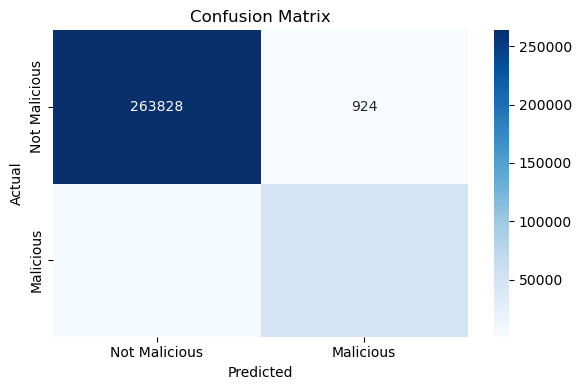

In [27]:
cm = confusion_matrix(y_test, y_pred_label)
print(cm)
print(classification_report(y_test, y_pred_label))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Malicious', 'Malicious'], yticklabels=['Not Malicious', 'Malicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

##### Still overfitting with a recall of 1

### 1C version with a lighter tokenizer, less layers and clean data

In [28]:
dff ['Payload_filled'] = dff['PayloadStrings'].fillna("<EMPTY>").astype(str)

In [29]:
dff_OP = dff[dff['Payload_filled'] != "<EMPTY>"].copy()

In [30]:
df=dff_OP

In [31]:
df.shape

(872000, 159)

In [32]:
#replace 'Benign' with 0 and 'Malicious' by 1
df['Label'] = df['Label'].replace({'Benign': 0, 'Malicious': 1})

In [ ]:
entropy_features = df.iloc[:, :10].values  # Next 10 columns (Entropy_1 to Entropy_10)
tcp_features = df.iloc[:, 10:154].values  # First 144 columns (binary TCP header)
payloads = df['Payload_filled'].astype(str)  # Text payload
labels = df['Label'].values  # Binary classification (0 = benign, 1 = malicious)

print(entropy_features)
print(tcp_features)
print(payloads)
print(labels)

[[0.38565713 0.37906545 0.37733936 ... 0.         0.         0.        ]
 [0.3690216  0.         0.         ... 0.         0.         0.        ]
 [0.37456676 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.3529272  0.38288453 0.38565713 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.36970118 0.         0.         ... 0.         0.         0.        ]]
[[0 1 0 ... 1 0 1]
 [0 1 0 ... 1 0 1]
 [0 1 0 ... 1 0 1]
 ...
 [0 1 0 ... 1 0 0]
 [0 1 0 ... 0 1 1]
 [0 1 0 ... 1 1 0]]
1          z=7Ж6VXVHтƒж
“aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...
8          ЬR†уRH'¶l
©HЭ÷W!F
у=#'t‘…jюч@SЙЭ‘3o$ющЖЄи[...
11         м~QUЗ9-[{■~B?■ОDZc1"у┴qt╓²┘D s25з≈<4d╚Z...
16                                               Dלפ,ˆי'"n¥~
17                                                N³r´ö-Õ{¦¡
                                 ...                        
1361357                                             ssh-rsa
1361358 

In [48]:
first_row = payloads[0]
print(len(first_row))

30


In [53]:
max_chars = max(payloads, key=len)
print("Longest row by character count:", max_chars)
print("Character count:", len(max_chars))

 -----BEGIN PGP SIGNED MESSAGE----- Hash: SHA512  Origin: Ubuntu Label: Ubuntu Suite: xenial-backports Version: 16.04 Codename: xenial Date: Thu, 15 Feb 2018 10:36:39 UTC Architectures: amd64 arm64 armhf i386 powerpc ppc64el s390x Components: main restricted universe multiverse Description: Ubuntu Xenial Backports NotAutomatic: yes ButAutomaticUpgrades: yes MD5Sum:  1b7c3a3dc05eae30cb628739554ef9c8           275370 Contents-powerpc  a5e9d27216dcb424f3defa79bc76be08            58691 Contents-armhf.gz  556a26e43a104cb3c66199d78ae1e18f           873187 Contents-armhf  d426634fa7c99477bf91b9654282577d            55462 Contents-ppc64el.gz  cc90af674d42ca797deb45f48af47c17           817822 Contents-arm64  d134cdb405961c0bdccdc78fa18b6b07           873835 Contents-amd64  21bf859f2cfe213fc505fb44009568ba            55320 Contents-s390x.gz  6462d4bc59427cf7ce4e777e548347a5            55295 Contents-arm64.gz  d33e5a1d9dede81f47e6c34b2a1f14a2            58826 Contents-amd64.gz  d4e369631d842c121e

In [54]:
row_char_counts = [len("".join(row)) for row in payloads]

max_index = row_char_counts.index(max(row_char_counts))
print("Row with highest character count:", payloads[max_index])
print("Character count:", row_char_counts[max_index])

Row with highest character count: rяФQ°1•6ьЉдкаVЙHУCA™вЫэ3,ZЬloќ:ЧхќI	Ѓ`›kвzЭЌpуTи3bц{‘™эЊЬf
Character count: 60816


In [61]:
import math

def get_top_1_percent_rows(payloads):
    # Ensure each row is treated as a string of characters
    char_counts = [len("".join(row)) for row in payloads]

    # Calculate how many rows make up the top 1%
    top_n = max(1, math.ceil(0.01 * len(payloads)))

    # Find the indices of the top 1% rows
    top_indices = sorted(range(len(char_counts)), key=lambda i: char_counts[i], reverse=True)[:top_n]

    # Display the results
    for idx in top_indices:
        print(f"Row {idx} -> Character Count: {char_counts[idx]} | Row Content: {payloads[idx]}")

# Example usage:
# get_top_1_percent_rows(payloads)

In [64]:
df1 = df[df['Payload_filled'].apply(lambda x: len(x) <= 10000)]

# Print the cleaned dataframe
print(df1)

         Entropy_1  Entropy_2  Entropy_3  Entropy_4  Entropy_5  Entropy_6  \
1         0.385657   0.379065   0.377339   0.000000   0.000000   0.000000   
8         0.369022   0.000000   0.000000   0.000000   0.000000   0.000000   
11        0.374567   0.000000   0.000000   0.000000   0.000000   0.000000   
16        0.373520   0.000000   0.000000   0.000000   0.000000   0.000000   
17        0.385657   0.000000   0.000000   0.000000   0.000000   0.000000   
...            ...        ...        ...        ...        ...        ...   
1361357   0.287351   0.369022   0.380112   0.381838   0.374567   0.377339   
1361358   0.287351   0.369022   0.380112   0.381838   0.374567   0.377339   
1361359   0.352927   0.382885   0.385657   0.377339   0.379065   0.000000   
1361362   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   
1361369   0.369701   0.000000   0.000000   0.000000   0.000000   0.000000   

         Entropy_7  Entropy_8  Entropy_9  Entropy_10  ...  Header_bit_140  

In [66]:
df=df1

In [67]:
entropy_features = df.iloc[:, :10].values  # Next 10 columns (Entropy_1 to Entropy_10)
tcp_features = df.iloc[:, 10:154].values  # First 144 columns (binary TCP header)
payloads = df['PayloadStrings'].fillna("<EMPTY>").astype(str)  # Text payload
labels = df['Label'].values  # Binary classification (0 = benign, 1 = malicious)

print(entropy_features)
print(tcp_features)
print(payloads)
print(labels)

[[0.38565713 0.37906545 0.37733936 ... 0.         0.         0.        ]
 [0.3690216  0.         0.         ... 0.         0.         0.        ]
 [0.37456676 0.         0.         ... 0.         0.         0.        ]
 ...
 [0.3529272  0.38288453 0.38565713 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.36970118 0.         0.         ... 0.         0.         0.        ]]
[[0 1 0 ... 1 0 1]
 [0 1 0 ... 1 0 1]
 [0 1 0 ... 1 0 1]
 ...
 [0 1 0 ... 1 0 0]
 [0 1 0 ... 0 1 1]
 [0 1 0 ... 1 1 0]]
1          z=7Ж6VXVHтƒж
“aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...
8          ЬR†уRH'¶l
©HЭ÷W!F
у=#'t‘…jюч@SЙЭ‘3o$ющЖЄи[...
11         м~QUЗ9-[{■~B?■ОDZc1"у┴qt╓²┘D s25з≈<4d╚Z...
16                                               Dלפ,ˆי'"n¥~
17                                                N³r´ö-Õ{¦¡
                                 ...                        
1361357                                             ssh-rsa
1361358 

In [68]:
#Tokenization and Padding of Payloads (Text Data)
tokenizer = Tokenizer(num_words=5000, oov_token="<UNK>")
tokenizer.fit_on_texts(payloads)
vocab_size = len(tokenizer.word_index) + 1
max_len = 100  # Max sequence length (adjust as needed)
payload_sequences = tokenizer.texts_to_sequences(payloads)
payload_padded = pad_sequences(payload_sequences, maxlen=max_len, padding='post')

In [69]:
X_tcp, X_tcp_test, X_entropy, X_entropy_test, X_payload, X_payload_test, y_train, y_test = train_test_split(
    tcp_features, entropy_features, payload_padded, labels, test_size=0.2, random_state=42
)

In [74]:
# Input Layer for TCP Header Features
tcp_input = Input(shape=(144,))
tcp_dense = Dense(16, activation='relu')(tcp_input)
tcp_dense = Dropout(0.3)(tcp_dense)
tcp_dense = Dense(8, activation='relu')(tcp_dense)
tcp_dense = Dropout(0.3)(tcp_dense)

# Input Layer for Entropy Features
entropy_input = Input(shape=(10,))
entropy_dense = Dense(16, activation='relu')(entropy_input)
entropy_dense = Dropout(0.3)(entropy_dense)
entropy_dense = Dense(8, activation='relu')(entropy_dense)

#Input Layer for Payload (Text)
payload_input = Input(shape=(max_len,))
embedding_layer = Embedding(vocab_size, 64, input_length=max_len)(payload_input)
lstm_layer = LSTM(64, dropout=0.3, recurrent_dropout=0.2)(embedding_layer)

#Merge all features
merged = Concatenate()([tcp_dense, entropy_dense, lstm_layer])
merged_dense = Dense(16, activation='relu')(merged)
merged_dense = Dropout(0.4)(merged_dense)
merged_dense = Dense(8, activation='relu')(merged_dense)
output = Dense(1, activation='sigmoid')(merged_dense)  # Sigmoid for binary classification

#Define and Compile Model
model = Model(inputs=[tcp_input, entropy_input, payload_input], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Model Summary
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 144)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │      2,320 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 16)        │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 16)        │        176 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 8)         │        136 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16)        │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 64)   │ 155,499,0… │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 8)         │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 8)         │        136 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     33,024 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 80)        │          0 │ dropout_9[0][0],  │
│ (Concatenate)       │                   │            │ dense_18[0][0],   │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 16)        │      1,296 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 16)        │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 8)         │        136 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1)         │          9 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 155,536,305 (593.32 MB)

 Trainable params: 155,536,305 (593.32 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [76]:
# Train Model
history = model.fit(
    [X_tcp, X_entropy, X_payload], y_train,
    validation_data=([X_tcp_test, X_entropy_test, X_payload_test], y_test),
    epochs=1, batch_size=32
)

21799/21799 ━━━━━━━━━━━━━━━━━━━━ 12162s 558ms/step - accuracy: 0.9883 - loss: 0.0388 - val_accuracy: 0.9987 - val_loss: 0.0059


In [77]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model1.predict([X_tcp_test, X_entropy_test, X_payload_test])
y_pred_label = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred_label))
print(classification_report(y_test, y_pred_label))

5450/5450 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step
[[150659    571]
 [   169  22992]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    151230
           1       0.98      0.99      0.98     23161

    accuracy                           1.00    174391
   macro avg       0.99      0.99      0.99    174391
weighted avg       1.00      1.00      1.00    174391



Confusion Matrix:
 [[150659    571]
 [   169  22992]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    151230
           1       0.98      0.99      0.98     23161

    accuracy                           1.00    174391
   macro avg       0.99      0.99      0.99    174391
weighted avg       1.00      1.00      1.00    174391



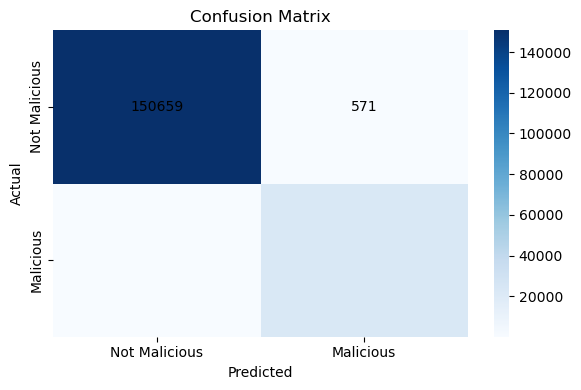

In [81]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_label)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_label))

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Malicious', 'Malicious'],
            yticklabels=['Not Malicious', 'Malicious'],
            annot_kws={"color": "black"})  # ensures visibility
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [82]:
model.save("final_multi_input.keras")

## Approach 2 A

#### Simple NLP approach, using LSTM

In this approach I am using only the payload string with an LSTM-based NLP model to predict malicious vs non-malicious payloads
Payloads often contain distinct patterns, command strings, or anomalous syntax that LSTMs can learn to recognize as malicious.

This technique is especially valuable: 
> we want to focus only on the semantic content of the payload (e.g. SQLi, XSS, malware command patterns).
> we aim for portability (model doesn’t rely on TCP header structure, which varies across protocols).

Advantages of this model is that 
> LSTM captures the sequence and structure of strings (e.g., shell commands, exploits, scripts).
> NLP models treat raw text as input. No manual work to extract entropy, flags, header bits.
> Doesn't rely on TCP/IP details; works with HTTP, SMTP, etc.


In [55]:
payloads_f = dff['PayloadStrings'].fillna("<EMPTY>").astype(str)  # getting the payload text

In [56]:
tokenizer.fit_on_texts(payloads_f)
vocab_size = len(tokenizer.word_index) + 1
max_len = 100  # Max sequence length
payload_sequences_f = tokenizer.texts_to_sequences(payloads_f)
payload_padded_f = pad_sequences(payload_sequences_f, maxlen=max_len, padding='post')

In [57]:
labels_f = dff['Label']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    payload_padded_f, labels_f, test_size=0.2, random_state=42)

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [60]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

C:\Users\susmi\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [36]:
history_lt = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1045s 18ms/step - accuracy: 0.9374 - loss: 0.2290 - val_accuracy: 0.9426 - val_loss: 0.2012
Epoch 2/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1039s 18ms/step - accuracy: 0.9414 - loss: 0.2049 - val_accuracy: 0.9427 - val_loss: 0.2007
Epoch 3/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1039s 18ms/step - accuracy: 0.9414 - loss: 0.2045 - val_accuracy: 0.9427 - val_loss: 0.2008
Epoch 4/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1037s 18ms/step - accuracy: 0.9417 - loss: 0.2039 - val_accuracy: 0.9427 - val_loss: 0.2006
Epoch 5/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1044s 18ms/step - accuracy: 0.9414 - loss: 0.2044 - val_accuracy: 0.9427 - val_loss: 0.2006
Epoch 6/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1047s 18ms/step - accuracy: 0.9415 - loss: 0.2044 - val_accuracy: 0.9426 - val_loss: 0.2011
Epoch 7/10
58809/58809 ━━━━━━━━━━━━━━━━━━━━ 1093s 19ms/step - accuracy: 0.9417 - loss: 0.2038 - val_accuracy: 0.9426 - val_loss: 0.2016


In [37]:
model.save("model_NLP_K.keras")

## Approach 2 B

#### This is the same as the above approach, but just removing EMPTY rows of the payload column

In [70]:
dff ['Payload_filled'] = dff['PayloadStrings'].fillna("<EMPTY>").astype(str)

In [71]:
dff

,Entropy_1,Entropy_2,Entropy_3,Entropy_4,Entropy_5,Entropy_6,Entropy_7,Entropy_8,Entropy_9,Entropy_10,...,Header_bit_140,Header_bit_141,Header_bit_142,Header_bit_143,Header_bit_144,PayloadEncoding,PayloadStrings,Attack,Label,Payload_filled
0,0.385657,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,1,0,1,None,None,Benign,0,<EMPTY>
1,0.385657,0.379065,0.377339,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,1,0,1,MacCyrillic,z=7Ж6VXVHтƒж “aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...,Benign,0,z=7Ж6VXVHтƒж “aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...
2,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,None,None,Benign,0,<EMPTY>
3,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,1,1,1,None,None,Benign,0,<EMPTY>
4,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,1,1,0,None,None,Benign,0,<EMPTY>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361373,0.374567,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,1,0,None,None,Benign,0,<EMPTY>
1361374,0.380112,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,1,None,None,Benign,0,<EMPTY>
1361375,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,1,0,None,None,Benign,0,<EMPTY>
1361376,0.377339,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,1,1,None,None,Benign,0,<EMPTY>


In [72]:
dff_OP = dff[dff['Payload_filled'] != "<EMPTY>"].copy()

In [74]:
dff_OP

,Entropy_1,Entropy_2,Entropy_3,Entropy_4,Entropy_5,Entropy_6,Entropy_7,Entropy_8,Entropy_9,Entropy_10,...,Header_bit_140,Header_bit_141,Header_bit_142,Header_bit_143,Header_bit_144,PayloadEncoding,PayloadStrings,Attack,Label,Payload_filled
1,0.385657,0.379065,0.377339,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,1,1,0,1,MacCyrillic,z=7Ж6VXVHтƒж “aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...,Benign,0,z=7Ж6VXVHтƒж “aВ:`аs∞ѕ/Эn„:«ЗЌ8—џjТєёи≤p#Ї“...
8,0.369022,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,1,1,0,1,MacCyrillic,ЬR†уRH'¶l ©HЭ÷W!F у=#'t‘…jюч@SЙЭ‘3o$ющЖЄи[...,Benign,0,ЬR†уRH'¶l ©HЭ÷W!F у=#'t‘…jюч@SЙЭ‘3o$ющЖЄи[...
11,0.374567,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,1,1,0,1,KOI8-R,"м~QUЗ9-[{■~B?■ОDZc1""у┴qt╓²┘D s25з≈<4d╚Z...",Benign,0,"м~QUЗ9-[{■~B?■ОDZc1""у┴qt╓²┘D s25з≈<4d╚Z..."
16,0.373520,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,1,1,0,1,None,"Dלפ,ˆי'""n¥~",Benign,0,"Dלפ,ˆי'""n¥~"
17,0.385657,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,1,1,0,1,None,N³r´ö-Õ{¦¡,Benign,0,N³r´ö-Õ{¦¡
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361357,0.287351,0.369022,0.380112,0.381838,0.374567,0.377339,0.381838,0.385657,0.385657,0.377339,...,0,0,1,1,0,None,ssh-rsa,Benign,0,ssh-rsa
1361358,0.287351,0.369022,0.380112,0.381838,0.374567,0.377339,0.381838,0.385657,0.385657,0.377339,...,0,0,1,1,0,None,ssh-rsa,Benign,0,ssh-rsa
1361359,0.352927,0.382885,0.385657,0.377339,0.379065,0.000000,0.000000,0.000000,0.000000,0.000000,...,1,0,1,0,0,Windows-1252,7¦­>“·Ž˜uEòî¸ÇË,Benign,0,7¦­>“·Ž˜uEòî¸ÇË
1361362,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,1,1,ISO-8859-7,$ΉΆώεύωΩ¬,Benign,0,$ΉΆώεύωΩ¬


In [77]:
payloads_f1 = dff_OP['Payload_filled'].astype(str)  # getting the payload text

In [78]:
tokenizer.fit_on_texts(payloads_f1)
vocab_size = len(tokenizer.word_index) + 1
max_len = 100  # Max sequence length (adjust as needed)
payload_sequences_f1 = tokenizer.texts_to_sequences(payloads_f1)
payload_padded_f1 = pad_sequences(payload_sequences_f1, maxlen=max_len, padding='post')

In [79]:
labels_f1 = dff_OP['Label']

In [80]:
print(labels_f1)

1          0
8          0
11         0
16         0
17         0
          ..
1361357    0
1361358    0
1361359    0
1361362    0
1361369    0
Name: Label, Length: 872000, dtype: int64


In [81]:
X_trainz, X_testz, y_trainz, y_testz = train_test_split(
    payload_padded_f1, labels_f1, test_size=0.2, random_state=42)

In [82]:
modelz = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

modelz.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

modelz.summary()

C:\Users\susmi\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [83]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [84]:
history_ltz = modelz.fit(
    X_trainz, y_trainz,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
17440/17440 ━━━━━━━━━━━━━━━━━━━━ 374s 21ms/step - accuracy: 0.9824 - loss: 0.0668 - val_accuracy: 0.9962 - val_loss: 0.0161
Epoch 2/5
17440/17440 ━━━━━━━━━━━━━━━━━━━━ 373s 21ms/step - accuracy: 0.9962 - loss: 0.0178 - val_accuracy: 0.9963 - val_loss: 0.0159
Epoch 3/5
17440/17440 ━━━━━━━━━━━━━━━━━━━━ 395s 23ms/step - accuracy: 0.9916 - loss: 0.0327 - val_accuracy: 0.9962 - val_loss: 0.0158
Epoch 4/5
17440/17440 ━━━━━━━━━━━━━━━━━━━━ 382s 22ms/step - accuracy: 0.9963 - loss: 0.0156 - val_accuracy: 0.9963 - val_loss: 0.0157
Epoch 5/5
17440/17440 ━━━━━━━━━━━━━━━━━━━━ 382s 22ms/step - accuracy: 0.9962 - loss: 0.0155 - val_accuracy: 0.9962 - val_loss: 0.0159


In [ ]:
y_predz = modelz.predict([X_testz])
y_pred_labelz = (y_predz > 0.5).astype(int)

print(confusion_matrix(y_testz, y_pred_labelz))
print(classification_report(y_testz, y_pred_labelz))


In [86]:
modelz.save("model_NLP_K2_clean.keras")

In [ ]:
cmz = confusion_matrix(y_testz, y_pred_labelz)
print(cmz)
print(classification_report(y_testz, y_pred_labelz))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Malicious', 'Malicious'], yticklabels=['Not Malicious', 'Malicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()